# Research Paper Topic Mapping

**Objective:** Map paper abstracts into interpretable research themes and surface nearby work through vector similarity.

This notebook uses deterministic demo text so the entire unsupervised workflow remains executable offline. Generator topics are hidden from model fitting and used only for retrospective diagnostics.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Build the documented demo corpus


In [2]:
TOPICS = {
  "language_models": [
    "transformer",
    "language",
    "attention",
    "token",
    "instruction",
    "reasoning",
    "benchmark",
    "generation"
  ],
  "computer_vision": [
    "image",
    "vision",
    "pixel",
    "segmentation",
    "detection",
    "camera",
    "feature",
    "scene"
  ],
  "ml_systems": [
    "serving",
    "latency",
    "distributed",
    "training",
    "memory",
    "throughput",
    "hardware",
    "pipeline"
  ],
  "responsible_ai": [
    "fairness",
    "privacy",
    "bias",
    "safety",
    "audit",
    "governance",
    "risk",
    "explainability"
  ]
}
ENTITY = "abstract"
COMMON_WORDS = ["customer", "system", "request", "team", "today", "information", "service", "workflow"]
rows = []
for topic, vocabulary in TOPICS.items():
    for row_id in range(75):
        tokens = rng.choice(vocabulary, size=7, replace=True).tolist()
        tokens += rng.choice(COMMON_WORDS, size=4, replace=True).tolist()
        if rng.random() < 0.45:
            other_topic = rng.choice([name for name in TOPICS if name != topic])
            tokens += rng.choice(TOPICS[other_topic], size=2, replace=True).tolist()
        rng.shuffle(tokens)
        rows.append({"text": " ".join(tokens), "generator_topic": topic, "record_id": f"{topic[:3]}-{row_id:03d}"})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Corpus: {len(data):,} {ENTITY} records")
display(data.head())
display(data["generator_topic"].value_counts().rename("records").to_frame())


Corpus: 300 abstract records


,text,generator_topic,record_id
0,training today memory distributed distributed ...,ml_systems,ml_-053
1,workflow bias service governance bias request ...,responsible_ai,res-041
2,workflow serving transformer distributed distr...,ml_systems,ml_-002
3,request token customer token benchmark generat...,language_models,lan-009
4,information audit bias request bias request pr...,responsible_ai,res-008


,records
generator_topic,
ml_systems,75
responsible_ai,75
language_models,75
computer_vision,75


## 3. TF-IDF representation and cluster selection


In [3]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, silhouette_score

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=500, sublinear_tf=True)
vectors = vectorizer.fit_transform(data["text"])
print(f"Vector matrix: {vectors.shape[0]} documents × {vectors.shape[1]} features")

selection_rows = []
for k in range(2, 7):
    candidate = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = candidate.fit_predict(vectors)
    selection_rows.append({"k": k, "silhouette": silhouette_score(vectors, labels, metric="cosine"), "inertia": candidate.inertia_})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))

best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
model = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
data["cluster"] = model.fit_predict(vectors)
print(f"Selected k={best_k} from cosine silhouette; score={selection['silhouette'].max():.4f}")


Vector matrix: 300 documents × 500 features
Selected k=4 from cosine silhouette; score=0.1426


,k,silhouette,inertia
0,2,0.0788,264.1854
1,3,0.1109,252.1955
2,4,0.1426,240.5170
3,5,0.1175,237.9959
4,6,0.0966,235.6345


## 4. Interpret discovered clusters


In [4]:
terms = np.asarray(vectorizer.get_feature_names_out())
top_terms = []
for cluster_id, center in enumerate(model.cluster_centers_):
    words = terms[np.argsort(center)[-10:][::-1]]
    top_terms.append({"cluster": cluster_id, "records": int((data["cluster"] == cluster_id).sum()), "top_terms": ", ".join(words)})
display(pd.DataFrame(top_terms))
display(pd.crosstab(data["generator_topic"], data["cluster"], margins=True))
ari = adjusted_rand_score(data["generator_topic"], data["cluster"])
print(f"Retrospective ARI against hidden generator topics: {ari:.4f}")
print("The generator topic was not provided to TF-IDF or K-Means.")


Retrospective ARI against hidden generator topics: 1.0000
The generator topic was not provided to TF-IDF or K-Means.


,cluster,records,top_terms
0,0,75,"safety, bias, audit, governance, privacy, expl..."
1,1,75,"distributed, latency, serving, memory, hardwar..."
2,2,75,"instruction, token, reasoning, language, bench..."
3,3,75,"scene, feature, vision, pixel, image, segmenta..."


cluster,0,1,2,3,All
generator_topic,,,,,
computer_vision,0,0,0,75,75
language_models,0,0,75,0,75
ml_systems,0,75,0,0,75
responsible_ai,75,0,0,0,75
All,75,75,75,75,300


## 5. Two-dimensional map and stability check


Cluster stability across two random seeds (ARI): 1.0000


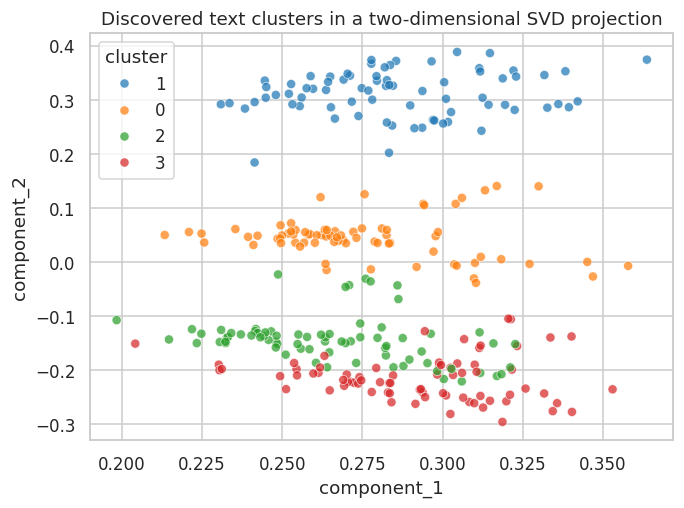

In [5]:
from sklearn.decomposition import TruncatedSVD

projection = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(vectors)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.72)
plt.title("Discovered text clusters in a two-dimensional SVD projection")
plt.tight_layout()
plt.show()

alternate = KMeans(n_clusters=best_k, n_init=30, random_state=7).fit_predict(vectors)
stability = adjusted_rand_score(data["cluster"], alternate)
print(f"Cluster stability across two random seeds (ARI): {stability:.4f}")


## 6. Assign new text and inspect nearest records


In [6]:
from sklearn.metrics.pairwise import cosine_similarity

probe = " ".join(list(TOPICS.values())[0][:5])
probe_vector = vectorizer.transform([probe])
probe_cluster = int(model.predict(probe_vector)[0])
similarities = cosine_similarity(probe_vector, vectors).ravel()
nearest = np.argsort(similarities)[-5:][::-1]
print(f"Probe: {probe}")
print(f"Assigned cluster: {probe_cluster}")
display(data.loc[nearest, ["record_id", "text", "cluster"]].assign(cosine_similarity=similarities[nearest]).round(4))


Probe: transformer language attention token instruction
Assigned cluster: 2


,record_id,text,cluster,cosine_similarity
190,lan-061,workflow system attention information transfor...,2,0.4404
278,lan-048,language attention benchmark customer language...,2,0.3601
68,lan-056,attention system customer workflow transformer...,2,0.3494
139,lan-002,token system instruction token information ben...,2,0.3362
281,lan-021,attention information request camera attention...,2,0.3245


## 7. Findings and limitations

- Cluster quality is evaluated with cohesion, stability, interpretable terms, and a hidden synthetic diagnostic.
- The synthetic corpus proves the workflow, not production accuracy.
- Production use should replace TF-IDF with validated domain embeddings when semantic nuance matters.
- Topics should be reviewed by domain experts before they drive routing or policy decisions.
